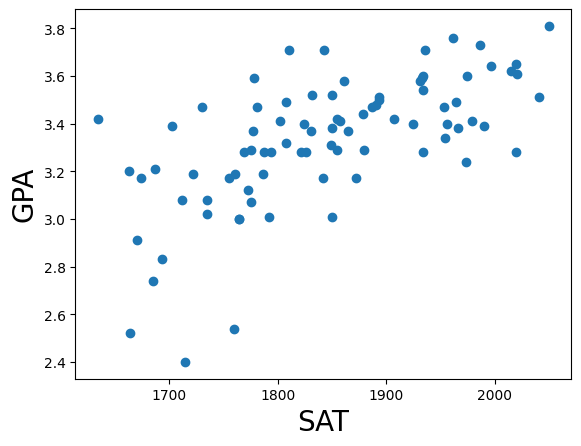

3.3925000000000005  |  3.51
3.2749999999999995  |  3.52
3.2949999999999995  |  3.52
3.3975000000000004  |  3.54
3.295  |  3.58
3.3974999999999995  |  3.58
3.3975000000000004  |  3.59
3.2587500000000005  |  3.59
3.3899999999999997  |  3.6
3.3975000000000004  |  3.6
3.3874999999999993  |  3.61
3.3874999999999993  |  3.62
3.3662499999999995  |  3.64
3.3874999999999993  |  3.65
3.2950000000000004  |  3.71
3.3975000000000004  |  3.71
3.30875  |  3.71
3.3662500000000004  |  3.73
3.37625  |  3.76
3.3874999999999993  |  3.81
MSE 0.08137789062500003
MAE 0.2711875000000001


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Change to data path on your computer
data = \
pd.read_csv("C:/Users/PC/OneDrive/Desktop/Học máy/Assignment/SAT_GPA (1).csv")
# Show the description of data
data.describe()
# Set to training data (x, y)
y = data['GPA']
x = data['SAT']
# Remind that we need to put component x_0 = 1 to x
plt.scatter(x,y)
plt.xlabel('SAT', fontsize = 20)
plt.ylabel('GPA', fontsize = 20)
plt.show()
k = 8
def distance(array, value):
  array = np.array(array)
  return abs(array - value)
def find_nearest_index(array, value, k):
  array_D = distance(array, value)
  return np.argsort(array_D)[:k]
data_len = len(x)
X_train = np.array(x[:64])
Y_train = np.array(y[:64])
X_test = np.array(x[64:data_len])
Y_test = np.array(y[64:data_len])
k = 8

Y_pred = np.zeros(len(X_test))
mse_check  = 0
mae_check  = 0
R_squared = 0

for i in range(len(X_test)):
  indexis = find_nearest_index(X_train, X_test[i], k)
  for id in indexis:
      Y_pred[i] = Y_pred[i] + Y_train[id]
  Y_pred[i] = Y_pred[i]/len(indexis)
  print(Y_pred[i], ' | ', Y_test[i])
  mean_train = np.mean(Y_pred)

  mse_check = mse_check + (Y_pred[i] - Y_test[i])**2
  mae_check = mae_check + abs(Y_pred[i] - Y_test[i])
print('MSE', mse_check/len(X_test))
print('MAE', mae_check/len(X_test))

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print('MSE:', mean_squared_error(Y_test, Y_pred))
print('MAE:', mean_absolute_error(Y_test, Y_pred))
print('R-Square:', r2_score(Y_test, Y_pred))

MSE: 0.08137789062500003
MAE: 0.2711875000000001
R-Square: -10.951518670142466


In [8]:
def knn_predict(X_train, Y_train, X_test,k):
  Y_pred = np.zeros(len(X_test))
  for i, X_test in enumerate(X_test):
    indexis = find_nearest_index(X_train, X_test[i], k)
    Y_pred[i] = np.mean(Y_train[indexis])
  return Y_pred

Ví dụ A2

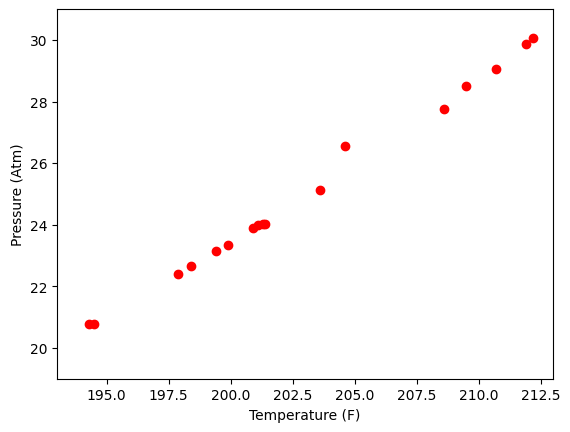

In [12]:
from __future__ import division, print_function, unicode_literals
import numpy as np
import matplotlib.pyplot as plt

#Temp (F degree)
X = np.array([[194.5, 194.3, 197.9, 198.4, 199.4, 199.9, 200.9, 201.1, 201.4, 201.3, 203.6, 204.6,  209.5, 208.6, 210.7, 211.9, 212.2]]).T

#Press (Atm)
Y = np.array([[20.79, 20.79, 22.4, 22.67, 23.15, 23.35, 23.89, 23.99, 24.02, 24.01, 25.14, 26.57, 28.49, 27.76, 29.04, 29.88, 30.06]]).T

plt.plot(X, Y, 'ro')
plt.axis([193, 213, 19, 31])
plt.xlabel("Temperature (F)")
plt.ylabel("Pressure (Atm)")
plt.show()

In [13]:
k = 4
def distance(array, value):
    array = np.array(array)
    return abs(array - value)

def find_nearest_index(array, value, k):
    array_D = distance(array, value)
    return np.argsort(array_D)[:k]

dat_len = len(X)
X_train = np.array(X[:16])
Y_train = np.array(Y[:16])

X_test = np.array(X[16:dat_len])
Y_test = np.array(Y[16:dat_len])
#np.linalg.norm(n - v, 2)

In [14]:
def knn_predict(X_train, Y_train, X_test, k):
    Y_pred = np.zeros(len(X_test))
    for i, x_test in enumerate(X_test):
        # Tìm k hàng xóm gần nhất
        indices = find_nearest_index(X_train, x_test, k)
        # Lấy trung bình Y_train của k hàng xóm
        Y_pred[i] = np.mean(Y_train[indices])
    return Y_pred

In [15]:
Y_pred = knn_predict(X_train, Y_train, X_test, k)
Y_pred

array([20.79])

In [16]:
mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print("Y_test:", Y_test.flatten())
print("Y_pred:", Y_pred)
print("MSE:", mse)
print("MAE:", mae)
print("R-Square:", r2)

Y_test: [30.06]
Y_pred: [20.79]
MSE: 85.93289999999999
MAE: 9.27
R-Square: nan


C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Ví Dụ 3A

In [17]:
import math
import numpy as np

In [20]:
with open('fuel.txt') as f:
    lines = f.readlines()

x_data = []
y_data = []
lines.pop(0)

for line in lines:
    splitted = line.replace('\n', '').split(',')
    splitted.pop(0)
    splitted = list(map(float, splitted))
    fuel = 1000 * splitted[1] / splitted[5]
    dlic = 1000 * splitted[0] / splitted[5]
    logMiles = math.log2(splitted[3])
    y_data.append([fuel])
    x_data.append([splitted[-1], dlic, splitted[2], logMiles])

x_data = np.asarray(x_data)
y_data = np.asanyarray(y_data)
x_data

array([[1.80000000e+01, 1.03138007e+03, 2.34710000e+04, 1.65271104e+01],
       [8.00000000e+00, 1.03164106e+03, 3.00640000e+04, 1.37342862e+01],
       [1.80000000e+01, 9.08597153e+02, 2.55780000e+04, 1.57535563e+01],
       [2.17000000e+01, 9.46570576e+02, 2.22570000e+04, 1.65824360e+01],
       [1.80000000e+01, 8.44703336e+02, 3.22750000e+04, 1.73647075e+01],
       [2.20000000e+01, 9.89606180e+02, 3.29490000e+04, 1.63895977e+01],
       [2.50000000e+01, 9.99593430e+02, 4.06400000e+04, 1.43519054e+01],
       [2.30000000e+01, 9.24344838e+02, 3.12550000e+04, 1.25053154e+01],
       [2.00000000e+01, 7.00195273e+02, 3.73830000e+04, 1.05830828e+01],
       [1.36000000e+01, 1.00012416e+03, 2.81450000e+04, 1.68398312e+01],
       [7.50000000e+00, 9.33302595e+02, 2.79400000e+04, 1.68179580e+01],
       [1.60000000e+01, 8.29997134e+02, 2.82210000e+04, 1.20627208e+01],
       [2.50000000e+01, 9.25193414e+02, 2.41800000e+04, 1.54990361e+01],
       [1.90000000e+01, 8.19436731e+02, 3.22590000e

In [21]:
data_length = len(x_data)
X_train = np.array(x_data[:40])
Y_train = np.array(y_data[:40])

X_test = np.array(x_data[40:data_length])
Y_test = np.array(y_data[40:data_length])
X_train

array([[1.80000000e+01, 1.03138007e+03, 2.34710000e+04, 1.65271104e+01],
       [8.00000000e+00, 1.03164106e+03, 3.00640000e+04, 1.37342862e+01],
       [1.80000000e+01, 9.08597153e+02, 2.55780000e+04, 1.57535563e+01],
       [2.17000000e+01, 9.46570576e+02, 2.22570000e+04, 1.65824360e+01],
       [1.80000000e+01, 8.44703336e+02, 3.22750000e+04, 1.73647075e+01],
       [2.20000000e+01, 9.89606180e+02, 3.29490000e+04, 1.63895977e+01],
       [2.50000000e+01, 9.99593430e+02, 4.06400000e+04, 1.43519054e+01],
       [2.30000000e+01, 9.24344838e+02, 3.12550000e+04, 1.25053154e+01],
       [2.00000000e+01, 7.00195273e+02, 3.73830000e+04, 1.05830828e+01],
       [1.36000000e+01, 1.00012416e+03, 2.81450000e+04, 1.68398312e+01],
       [7.50000000e+00, 9.33302595e+02, 2.79400000e+04, 1.68179580e+01],
       [1.60000000e+01, 8.29997134e+02, 2.82210000e+04, 1.20627208e+01],
       [2.50000000e+01, 9.25193414e+02, 2.41800000e+04, 1.54990361e+01],
       [1.90000000e+01, 8.19436731e+02, 3.22590000e

In [22]:
k = 4

def distance(array, value):
    array = np.array(array)
    return np.linalg.norm(array - value, ord=2, axis=1)


def find_nearest_index(array, value, k):
    array_D = distance(array, value)
    return np.argsort(array_D)[:k]

In [23]:
Y_pred = np.zeros(len(X_test))

for i in range(len(X_test)):
    indexis = find_nearest_index(X_train, X_test[i], k)
    for id in indexis:
        Y_pred[i] = Y_pred[i] + Y_train[id]
    Y_pred[i] = Y_pred[i]/len(indexis)
    print(Y_pred[i], ' | ', Y_test[i])

652.8546313611055  |  [711.73305769]
629.7764438184946  |  [697.05277706]
629.7764438184945  |  [638.23106095]
638.961615659754  |  [681.10013659]
658.8735491111272  |  [591.49994589]
662.0865068886196  |  [691.02271186]
610.0186827053449  |  [681.03112144]
599.7734001865958  |  [576.06974956]
662.9799139369711  |  [562.4109333]
535.2791544638845  |  [581.79371695]
662.0865068886196  |  [842.79175243]


C:\Users\PC\AppData\Local\Temp\ipykernel_29400\2425930744.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y_pred[i] = Y_pred[i] + Y_train[id]


In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print('MSE: ', mean_squared_error(Y_test, Y_pred))
print('MAE: ', mean_absolute_error(Y_test, Y_pred))
print('R-Square: ', r2_score(Y_test, Y_pred))

MSE:  5977.559602693981
MAE:  63.23296216814381
R-Square:  0.02094380947359953


Ví Dụ B1

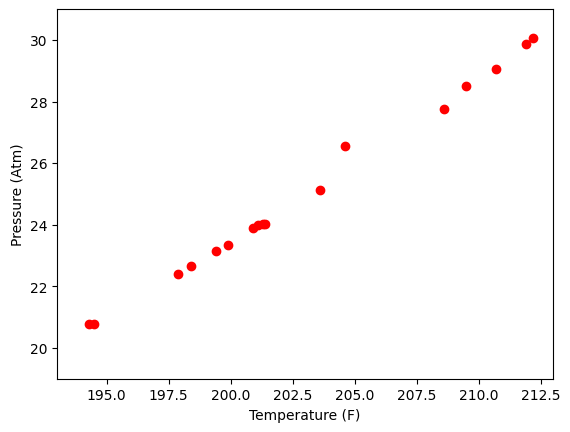

In [25]:
from __future__ import division, print_function, unicode_literals
import numpy as np
import matplotlib.pyplot as plt

#Temp (F degree)
X = np.array([[194.5, 194.3, 197.9, 198.4, 199.4, 199.9, 200.9, 201.1, 201.4, 201.3, 203.6, 204.6,  209.5, 208.6, 210.7, 211.9, 212.2]]).T

#Press (Atm)
Y = np.array([[20.79, 20.79, 22.4, 22.67, 23.15, 23.35, 23.89, 23.99, 24.02, 24.01, 25.14, 26.57, 28.49, 27.76, 29.04, 29.88, 30.06]]).T

plt.plot(X, Y, 'ro')
plt.axis([193, 213, 19, 31])
plt.xlabel("Temperature (F)")
plt.ylabel("Pressure (Atm)")
plt.show()

In [26]:
#Building Xbar
one = np.ones((X.shape[0], 1))
Xbar = np.concatenate((one, X), axis=1)

#Calculate weights of the fitting line
A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, Y)
w = np.dot(np.linalg.pinv(A), b)
print('w = ', w)

w =  [[-81.06372713]
 [  0.5228924 ]]


In [27]:
#Preparing the fitting line
w_0 = w[0][0]
w_1 = w[1][0]
x0 = np.linspace(193, 213, 2)
y0 = w_0 + w_1*x0

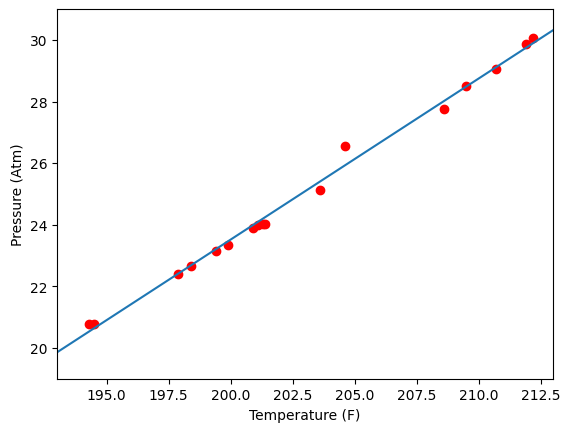

In [28]:
#Drawing the fitting line
plt.plot(X.T, Y.T, 'ro')
plt.plot(x0, y0)
plt.axis([193, 213, 19, 31])
plt.xlabel('Temperature (F)')
plt.ylabel('Pressure (Atm)')
plt.show()

Ví dụ 2B

In [3]:
import numpy as np
import math

In [4]:
with open('fuel.txt') as f:
    lines = f.readlines()

x_data = []
y_data = []
lines.pop(0)

for line in lines:
    splitted = line.replace('\n', '').split(',')
    splitted.pop(0)
    splitted = list(map(float, splitted))
    fuel = 1000 * splitted[1] / splitted[5]
    dlic = 1000 * splitted[0] / splitted[5]
    logMiles = math.log2(splitted[3])
    y_data.append([fuel])
    x_data.append([splitted[-1], dlic, splitted[2], logMiles])

x_data = np.asarray(x_data)
y_data = np.asarray(y_data)
x_data

array([[1.80000000e+01, 1.03138007e+03, 2.34710000e+04, 1.65271104e+01],
       [8.00000000e+00, 1.03164106e+03, 3.00640000e+04, 1.37342862e+01],
       [1.80000000e+01, 9.08597153e+02, 2.55780000e+04, 1.57535563e+01],
       [2.17000000e+01, 9.46570576e+02, 2.22570000e+04, 1.65824360e+01],
       [1.80000000e+01, 8.44703336e+02, 3.22750000e+04, 1.73647075e+01],
       [2.20000000e+01, 9.89606180e+02, 3.29490000e+04, 1.63895977e+01],
       [2.50000000e+01, 9.99593430e+02, 4.06400000e+04, 1.43519054e+01],
       [2.30000000e+01, 9.24344838e+02, 3.12550000e+04, 1.25053154e+01],
       [2.00000000e+01, 7.00195273e+02, 3.73830000e+04, 1.05830828e+01],
       [1.36000000e+01, 1.00012416e+03, 2.81450000e+04, 1.68398312e+01],
       [7.50000000e+00, 9.33302595e+02, 2.79400000e+04, 1.68179580e+01],
       [1.60000000e+01, 8.29997134e+02, 2.82210000e+04, 1.20627208e+01],
       [2.50000000e+01, 9.25193414e+02, 2.41800000e+04, 1.54990361e+01],
       [1.90000000e+01, 8.19436731e+02, 3.22590000e

In [5]:
def qr_householder(MAT):
    M = MAT.shape[0]
    N = MAT.shape[1]
    
    Q = np.identity(M)
    
    R = np.copy(MAT)
    
    for n in range(N):
        x = MAT[n:, n]
        k = x.shape[0]
        
        ro = -np.sign(x[0]) * np.linalg.norm(x)
        e = np.zeros(k)
        e[0] = 1
        v = (1 / (x[0] - ro)) * (x - (ro * e))
        
        for i in range(N):
            R[n:, i] = R[n:, i] - (2 / (v@v)) * ((np.outer(v,v)) @ R[n:, i])
            
        for i in range(M):
            Q[n:, i] = Q[n:, i] - (2 / (v@v)) * ((np.outer(v,v)) @ Q[n:, i])
    
    return Q.transpose(), R

def linear_regression(X, Y):
    x_bars = np.concatenate((np.ones((X.shape[0], 1)), X), axis=1)
    
    Q, R = qr_householder(x_bars)
    R_pinv = np.linalg.pinv(R)
    MAT = np.dot(R_pinv, Q.T)
    
    return np.dot(MAT, Y)

In [6]:
w = linear_regression(x_data, y_data)
w

array([[ 1.54192845e+02],
       [-4.22798321e+00],
       [ 4.71871213e-01],
       [-6.13533097e-03],
       [ 1.85452745e+01]])

In [8]:
line = ['Intercepter', 'Tax', 'Dlic', 'Income', 'LogMiles']
res = list(zip(line, w.flatten()))
for o in res:
    print('{: >20}: {: >10}'.format(*o))

         Intercepter: 154.19284457730794
                 Tax: -4.227983208329624
                Dlic: 0.4718712134419837
              Income: -0.0061353309704178065
            LogMiles: 18.545274506048024


B, Dùng sklearn

In [9]:
Xbar = np.concatenate((np.ones((x_data.shape[0], 1)), x_data), axis=1)

In [10]:
from sklearn import datasets, linear_model
regr = linear_model.LinearRegression(fit_intercept=False)
regr.fit(Xbar, y_data)

,fit_intercept,False
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
w = regr.coef_
line = ['Interceptor', 'Tax', 'Dlic', 'Income', 'LogMiles']
w_flat = w.flatten()  # Chuyển w thành mảng 1D
res = list(zip(line, w_flat))
for o in res:
    print('{: >20}: {: >10.4f}'.format(*o))

         Interceptor:   154.1928
                 Tax:    -4.2280
                Dlic:     0.4719
              Income:    -0.0061
            LogMiles:    18.5453


# Bài tập 1

In [12]:
X_train = x_data[:40,:]
Y_train = y_data[:40,:]

X_test = x_data[40:,:]
Y_test = y_data[40:,:]

w_train = linear_regression(X_train, Y_train)
w_train

array([[ 1.35142023e+02],
       [-1.90301193e+00],
       [ 4.18592399e-01],
       [-6.22943009e-03],
       [ 1.95938559e+01]])

In [13]:
X_test = np.concatenate([np.ones((X_test.shape[0], 1)), X_test], axis=1)
Y_pred = np.zeros((X_test.shape[0], 1))
for i in range(len(X_test)):
    Y_pred[i] = np.dot(w_train.T, X_test[i,:])
Y_pred

array([[649.91080195],
       [646.07167308],
       [649.73774387],
       [629.6843171 ],
       [632.36929804],
       [650.06180511],
       [595.88545846],
       [604.10563913],
       [625.93251769],
       [605.47408949],
       [633.96098858]])

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print("MSE: ", mean_squared_error(Y_test, Y_pred))
print("MAE: ", mean_absolute_error(Y_test, Y_pred))
print("R-Square: ", r2_score(Y_test, Y_pred))

MSE:  6253.362638613564
MAE:  60.61549039710425
R-Square:  -0.024229586967541072


# ví dụ  #B

In [15]:
from __future__ import division, print_function, unicode_literals
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [16]:
data = pd.read_csv('C:/Users/PC/OneDrive/Desktop/Học máy/Assignment/SAT_GPA (1).csv')
print(data.describe())

               SAT        GPA
count    84.000000  84.000000
mean   1845.273810   3.330238
std     104.530661   0.271617
min    1634.000000   2.400000
25%    1772.000000   3.190000
50%    1846.000000   3.380000
75%    1934.000000   3.502500
max    2050.000000   3.810000


In [17]:
X = data['SAT'].values.reshape(-1, 1)  # Shape: (n, 1)
Y = data['GPA'].values
corr, p_value = pearsonr(X.flatten(), Y)
print("Hệ số tương quan:", corr)
print("p-value:", p_value)

Hệ số tương quan: 0.6371843648401909
p-value: 7.199518436564236e-11


In [18]:
data_len = len(X)
X_train = X[:64]       # Shape: (64, 1)
Y_train = Y[:64]       # Shape: (64,)
X_test = X[64:]        # Shape: (n-64, 1)
Y_test = Y[64:]        # Shape: (n-64,)
X_test

array([[1893],
       [1832],
       [1850],
       [1934],
       [1861],
       [1931],
       [1933],
       [1778],
       [1975],
       [1934],
       [2021],
       [2015],
       [1997],
       [2020],
       [1843],
       [1936],
       [1810],
       [1987],
       [1962],
       [2050]])

In [19]:
one = np.ones((X_train.shape[0], 1))
Xbar = np.concatenate((one, X_train), axis=1)
Xbar

array([[1.000e+00, 1.714e+03],
       [1.000e+00, 1.664e+03],
       [1.000e+00, 1.760e+03],
       [1.000e+00, 1.685e+03],
       [1.000e+00, 1.693e+03],
       [1.000e+00, 1.670e+03],
       [1.000e+00, 1.764e+03],
       [1.000e+00, 1.764e+03],
       [1.000e+00, 1.792e+03],
       [1.000e+00, 1.850e+03],
       [1.000e+00, 1.735e+03],
       [1.000e+00, 1.775e+03],
       [1.000e+00, 1.735e+03],
       [1.000e+00, 1.712e+03],
       [1.000e+00, 1.773e+03],
       [1.000e+00, 1.872e+03],
       [1.000e+00, 1.755e+03],
       [1.000e+00, 1.674e+03],
       [1.000e+00, 1.842e+03],
       [1.000e+00, 1.786e+03],
       [1.000e+00, 1.761e+03],
       [1.000e+00, 1.722e+03],
       [1.000e+00, 1.663e+03],
       [1.000e+00, 1.687e+03],
       [1.000e+00, 1.974e+03],
       [1.000e+00, 1.826e+03],
       [1.000e+00, 1.787e+03],
       [1.000e+00, 1.821e+03],
       [1.000e+00, 2.020e+03],
       [1.000e+00, 1.794e+03],
       [1.000e+00, 1.769e+03],
       [1.000e+00, 1.934e+03],
       [

In [20]:
# Tính hệ số w = (Xbar^T * Xbar)^(-1) * Xbar^T * Y
A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, Y_train)
w = np.dot(np.linalg.pinv(A), b)
theta_0, theta_1 = w[0], w[1]
print(f"GPA = {theta_1:.4f} * SAT + {theta_0:.4f}")

GPA = 0.0013 * SAT + 0.8382


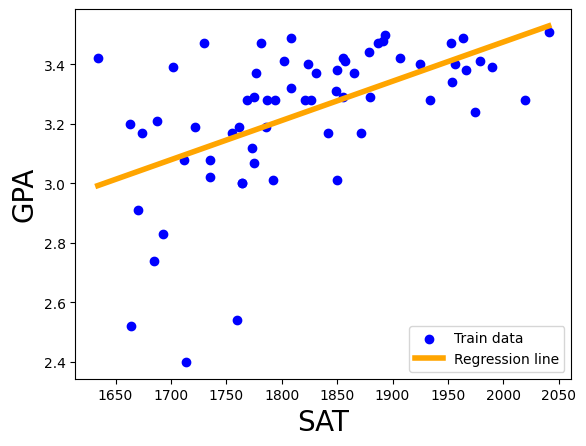

In [21]:
x0 = np.linspace(X_train.min(), X_train.max(), 100)
y0 = theta_0 + theta_1 * x0
plt.scatter(X_train, Y_train, color='blue', label='Train data')
plt.plot(x0, y0, lw=4, c='orange', label='Regression line')
plt.xlabel('SAT', fontsize=20)
plt.ylabel('GPA', fontsize=20)
plt.legend()
plt.show()

In [22]:
X_test_bar = np.concatenate((np.ones((X_test.shape[0], 1)), X_test), axis=1)
Y_pred_lr = np.dot(X_test_bar, w)
Y_pred_lr

array([3.33392082, 3.25349907, 3.27723007, 3.38797478, 3.29173236,
       3.38401961, 3.38665639, 3.18230604, 3.44202874, 3.38797478,
       3.50267465, 3.49476432, 3.47103331, 3.50135626, 3.26800135,
       3.39061156, 3.2244945 , 3.45784942, 3.42488968, 3.54090795])

In [23]:
print("MSE:", mean_squared_error(Y_test, Y_pred_lr))
print("MAE:", mean_absolute_error(Y_test, Y_pred_lr))
print("R-Square:", r2_score(Y_test, Y_pred_lr))

MSE: 0.07263824293838703
MAE: 0.24880371696885267
R-Square: -9.667975170860192


# ví dụ 4.B

In [24]:
import numpy as np
import math

In [25]:
with open('vidu4_lin_reg.txt') as f:
    lines = f.readlines()

x_data = []
y_data = []
lines.pop(0)

for line in lines:
    splitted = line.replace('\n', '').split(' ')
    splitted.pop(0)
    splitted = list(map(float, splitted))
    x_data.append(splitted[:-1])
    y_data.append(splitted[-1])

x_data = np.asarray(x_data)
y_data = np.asarray(y_data)
x_data

array([[ 56.  ,  21.  , 160.  ,  14.  ,   6.  ],
       [ 76.  ,  18.  , 150.  ,  12.  ,   4.97],
       [ 63.  ,  16.  , 160.  ,   4.4 ,   6.39],
       [ 78.  ,  20.  , 100.  ,   4.  ,   7.  ],
       [ 87.  ,  20.  , 110.  ,   4.6 ,   4.1 ],
       [ 76.  ,  19.  , 150.  ,   4.6 ,   2.74],
       [ 55.  ,  31.  , 160.  ,   5.5 ,   4.6 ],
       [ 74.  ,  22.  , 100.  ,   6.8 ,   5.04],
       [ 81.  ,  21.  , 120.  ,   5.8 ,   4.75],
       [ 77.  ,  24.  , 160.  ,   5.4 ,   6.94],
       [ 29.  ,  20.  , 120.  ,   3.8 ,   4.84],
       [ 71.  ,  22.  , 160.  ,   3.3 ,   6.63],
       [ 77.  ,  21.  , 160.  ,   5.1 ,   4.93],
       [ 59.  ,  18.  , 150.  ,   6.  ,   4.55],
       [ 58.  ,  27.  , 130.  ,   6.9 ,   6.7 ],
       [ 34.  ,  19.  , 130.  ,   4.5 ,   3.2 ],
       [ 74.  ,  22.  , 100.  ,  10.6 ,   4.3 ],
       [ 61.  ,  19.  , 170.  ,  18.  ,   6.8 ],
       [ 53.  ,  20.  , 130.  ,  25.  ,   5.5 ],
       [ 65.  ,  28.  , 140.  ,   6.5 ,   6.8 ],
       [ 80.  ,  19.

In [26]:
X_train = x_data
Y_train = y_data
Y_train

array([1.95, 1.33, 0.83, 2.  , 1.3 , 1.16, 1.  , 1.  , 0.8 , 1.6 , 0.65,
       1.  , 0.97, 0.73, 1.1 , 1.1 , 1.1 , 0.8 , 0.99, 1.  , 1.13, 1.  ,
       1.7 , 0.9 , 0.89, 0.8 , 0.81, 1.2 , 0.82, 0.89, 1.19, 0.97, 0.97,
       0.97, 0.88, 0.97, 0.9 , 0.89, 0.8 , 1.13, 1.2 , 0.9 , 0.81, 0.8 ,
       0.74, 2.66, 0.89, 0.79, 0.8 , 0.56, 0.8 , 1.2 , 0.82, 0.9 , 1.  ,
       1.15, 1.16, 0.97, 0.8 , 1.67, 1.06, 1.1 , 0.8 , 1.7 , 0.99, 1.16,
       0.62, 1.  , 0.82, 1.  , 1.7 , 2.3 , 0.89, 0.97, 0.7 , 1.1 , 1.01,
       1.15, 0.92, 1.1 , 0.8 , 0.7 , 1.  , 0.8 , 0.89, 0.6 , 1.5 , 0.7 ,
       1.1 , 0.81, 0.7 , 0.71, 2.7 , 1.13, 1.7 , 0.9 , 1.16, 1.  , 0.97,
       2.3 ])

In [27]:
def qr_householder(MAT):
    M = MAT.shape[0]
    N = MAT.shape[1]
    
    Q = np.identity(M)
    
    R = np.copy(MAT)
    
    for n in range(N):
        x = MAT[n:, n]
        k = x.shape[0]
        
        ro = - np.sign(x[0]) * np.linalg.norm(x)
        
        e = np.zeros(k)
        e[0] = 1
        v = (1 / (x[0] - ro) * (x - (ro * e)))
        
        for i in range(N):
            R[n:, i] = R[n:, i] - (2 / (v@v)) * ((np.outer(v,v)) @ R[n:, i])
            
        for i in range(M):
            Q[n:, i] = Q[n: ,i] - (2 / (v@v)) * ((np.outer(v,v)) @ Q[n:, i])
    return Q.transpose(), R

def linear_regression(X, Y):
    x_bars = np.concatenate((np.ones((X.shape[0], 1)), X), axis=1)
    
    Q, R = qr_householder(x_bars)
    R_pinv = np.linalg.pinv(R)
    MAT = np.dot(R_pinv, Q.T)
    
    return np.dot(MAT, Y)

In [28]:
w = linear_regression(X_train, Y_train)
w

array([-0.10802908,  0.00994694, -0.00020655,  0.00218137,  0.0076701 ,
        0.03847025])

In [29]:
Train_size = int(0.8 * len(x_data))
X_train = x_data[:Train_size]
Y_train = y_data[:Train_size]

X_test = x_data[Train_size:]
Y_test = y_data[Train_size:]

X_test = np.concatenate([np.ones((X_test.shape[0], 1)), X_test], axis=1)

X_test

array([[  1.  ,  49.  ,  24.  , 140.  ,   4.3 ,   5.5 ],
       [  1.  ,  36.  ,  23.  , 140.  ,   4.3 ,   4.2 ],
       [  1.  ,  74.  ,  21.  , 140.  ,  17.  ,   3.3 ],
       [  1.  ,  53.  ,  21.  , 140.  ,   5.6 ,   5.9 ],
       [  1.  ,  56.  ,  19.  , 140.  ,   4.1 ,   4.73],
       [  1.  ,  60.  ,  20.  , 160.  ,   4.9 ,   3.  ],
       [  1.  ,  83.  ,  21.  , 120.  ,   7.9 ,   5.88],
       [  1.  ,  68.  ,  23.  , 130.  ,   4.  ,   5.39],
       [  1.  ,  69.  ,  19.  , 100.  ,   4.4 ,   6.15],
       [  1.  ,  31.  ,  21.  , 120.  ,   4.1 ,   3.94],
       [  1.  ,  34.  ,  21.  , 140.  ,   6.7 ,   3.83],
       [  1.  ,  41.  ,  20.  , 120.  ,   2.7 ,   4.93],
       [  1.  ,  72.  ,  22.  , 160.  ,   6.4 ,   7.  ],
       [  1.  ,  54.  ,  22.  , 170.  ,   6.2 ,   8.18],
       [  1.  ,  54.  ,  28.  , 150.  ,   4.2 ,   8.16],
       [  1.  ,  55.  ,  24.  , 160.  ,   5.  ,   7.2 ],
       [  1.  ,  76.  ,  15.  , 140.  ,   3.1 ,   5.24],
       [  1.  ,  70.  ,  25.  ,

In [30]:
w = linear_regression(X_train, Y_train)
w

array([ 0.04306436,  0.0089892 , -0.00047742,  0.00260218,  0.00808634,
        0.00708535])

In [31]:
Y_pred = np.zeros((len(X_test),1))
Y_pred

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [32]:
for i in range(len(X_test)):
    Y_pred[i] = np.dot(w.T, X_test[i])
Y_pred

array([[0.91012272],
       [0.78452963],
       [1.22339369],
       [0.96085817],
       [0.96836123],
       [1.05009561],
       [1.19694736],
       [1.0521678 ],
       [0.9936207 ],
       [0.68503543],
       [0.78429172],
       [0.77109845],
       [1.19748204],
       [1.06844174],
       [0.99721921],
       [1.03380704],
       [1.14558205],
       [1.19228584],
       [1.29236178],
       [1.26252546]])

In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print("MSE: ", mean_squared_error(Y_test, Y_pred))
print("MAE: ", mean_absolute_error(Y_test, Y_pred))
print("R-Square: ", r2_score(Y_test, Y_pred))

print("Mean: ", np.mean(Y_pred))
print("Variance: ", np.var(Y_pred))

MSE:  0.22740099167615915
MAE:  0.3053259833743659
R-Square:  0.214538939386403
Mean:  1.0285113830380284
Variance:  0.029513550369571578


5B linear regression

In [34]:
import numpy as np
import pandas as pd

In [35]:
house = pd.read_csv('C:/Users/PC/OneDrive/Desktop/Học máy/Assignment/real_estate.csv')
house.head(5)

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [36]:
data = house.iloc[:,1:]
data.iloc[:, 0] = data.iloc[:, 0].apply(lambda x: int(float(x)))
data

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.0,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.0,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.0,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.0,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.0,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...
409,2013.0,13.7,4082.01500,0,24.94155,121.50381,15.4
410,2012.0,5.6,90.45606,9,24.97433,121.54310,50.0
411,2013.0,18.8,390.96960,7,24.97923,121.53986,40.6
412,2013.0,8.1,104.81010,5,24.96674,121.54067,52.5


In [37]:
X_train = data.iloc[:350,:6]
Y_train = data.iloc[:350,6]

X_test = data.iloc[350:,:6]
Y_test = data.iloc[350:,6]

X_test

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
350,2013.0,13.2,492.23130,5,24.96515,121.53737
351,2012.0,4.0,2180.24500,3,24.96324,121.51241
352,2012.0,18.4,2674.96100,3,24.96143,121.50827
353,2013.0,4.1,2147.37600,3,24.96299,121.51284
354,2013.0,12.2,1360.13900,1,24.95204,121.54842
...,...,...,...,...,...,...
409,2013.0,13.7,4082.01500,0,24.94155,121.50381
410,2012.0,5.6,90.45606,9,24.97433,121.54310
411,2013.0,18.8,390.96960,7,24.97923,121.53986
412,2013.0,8.1,104.81010,5,24.96674,121.54067


In [38]:
def qr_householder(MAT):
    M = MAT.shape[0]
    N = MAT.shape[1]
    
    Q = np.identity(M)
    
    R = np.copy(MAT)
    
    for n in range(N):
        x = MAT[n:, n]
        k = x.shape[0]
        
        ro = - np.sign(x[0]) * np.linalg.norm(x)
        
        e = np.zeros(k)
        e[0] = 1
        v = (1 / (x[0] - ro) * (x - (ro * e)))
        
        for i in range(N):
            R[n:, i] = R[n:, i] - (2 / (v@v)) * ((np.outer(v,v)) @ R[n:, i])
            
        for i in range(M):
            Q[n:, i] = Q[n: ,i] - (2 / (v@v)) * ((np.outer(v,v)) @ Q[n:, i])
    return Q.transpose(), R

def linear_regression(X, Y):
    x_bars = np.concatenate((np.ones((X.shape[0], 1)), X), axis=1)
    
    Q, R = qr_householder(x_bars)
    R_pinv = np.linalg.pinv(R)
    MAT = np.dot(R_pinv, Q.T)
    
    return np.dot(MAT, Y)

In [39]:
w = linear_regression(X_train, Y_train)
w

array([-1.08906135e+04,  2.86647401e+00, -2.87179387e-01, -4.02217786e-03,
        1.17396673e+00,  2.65624222e+02, -1.20827541e+01])

In [40]:
Y_pred = np.zeros((len(X_test), 1))
X_test.insert(0, 'interceptor', 1)
for i in range(len(X_test)):
    Y_pred[i] = np.dot(w.T, X_test.iloc[i,:])
Y_pred

array([[42.54030155],
       [32.97269639],
       [26.41672023],
       [35.87105578],
       [31.0248869 ],
       [49.76694586],
       [39.42524526],
       [52.45951948],
       [48.49656768],
       [28.19158719],
       [46.22188057],
       [40.97419479],
       [44.63563737],
       [48.84841737],
       [41.77323989],
       [29.62573805],
       [25.6233954 ],
       [30.3920993 ],
       [39.78513708],
       [28.29592085],
       [44.12448048],
       [43.39412219],
       [40.53424293],
       [45.15810455],
       [48.90500309],
       [30.4680322 ],
       [33.73228189],
       [48.7071821 ],
       [40.14085729],
       [51.4837938 ],
       [47.50787738],
       [54.88281387],
       [15.03524112],
       [37.39230465],
       [13.11314356],
       [53.29845141],
       [40.47774616],
       [31.8682795 ],
       [33.89845347],
       [40.17559964],
       [43.68289683],
       [30.22066183],
       [39.17132828],
       [44.69307325],
       [15.53320623],
       [38

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print("MSE: ", mean_squared_error(Y_test, Y_pred))
print("MAE: ", mean_absolute_error(Y_test, Y_pred))
print("R-Square: ", r2_score(Y_test, Y_pred))

MSE:  63.80695061606576
MAE:  6.032604707857454
R-Square:  0.6001833401130152


So sánh với KNN k =18

In [42]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [43]:
X_test = data.iloc[350:,:6]

In [44]:
scaler = StandardScaler()
X_train_knn = scaler.fit_transform(X_train)
X_test_knn = scaler.transform(X_test)

In [45]:
knn = KNeighborsRegressor(n_neighbors=18)
knn.fit(X_train_knn, Y_train)

,n_neighbors,18
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [46]:
Y_pred_knn = knn.predict(X_test_knn)

In [47]:
print("MSE:", mean_squared_error(Y_test, Y_pred_knn))
print("MAE:", mean_absolute_error(Y_test, Y_pred_knn))
print("R-Square:", r2_score(Y_test, Y_pred_knn))

MSE: 54.29407552083333
MAE: 5.830121527777777
R-Square: 0.659791359455351
